proposed method: HB-MC/HB-AL/HB-SA

- problem: mixed network
- origin:《Deterministic network interdiction optimization via an evolutionary approach》Ex-C
- env: Tensorflow (python 3.9.16)

In [1]:
%reset -f

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pickle
import time
from HB_function import *
from scipy.stats import norm,gamma
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout
import random
import tensorflow as tf
import itertools
import scipy.io as sio
from scipy.special import erf

In [3]:
## network setting
edges = [(1, 2), (2, 3), (1, 4), (2, 5), (3, 6), (4, 5), 
         (5, 6), (4, 7), (5, 8), (6, 9), (7, 8), (8, 9)]
nodes = set(node for edge in edges for node in edge)
terminals = [1, 9];    
num_nodes = len(nodes)   
num_edges = len(edges)  
num_terminals =len(terminals)
m=(num_nodes+num_edges-num_terminals)
M=m+1

S = 4  
exp_nodes_lambda12 = [3, 5, 7]        
exp_nodes_lambda07 = [2, 4, 6, 8]    
infinite_nodes     = [1, 9]        
weibull_edges = [1, 2, 6, 7, 11, 12]  
lognorm_edges = [3, 4, 5, 8, 9, 10]  

n1 = len(exp_nodes_lambda12)   
n2 = len(exp_nodes_lambda07)   
n3 = len(weibull_edges)        
n4 = len(lognorm_edges)       
N = [n1, n2, n3, n4]

lambda1 = 1.2
lambda2 = 0.7
weibull_a = 1.5; weibull_b = 3.6
lognorm_mu = 1.5; lognorm_sigma = 2.6

def F_exp1(t):
    return 1 - np.exp(-lambda1 * t)
def F_exp2(t):
    return 1 - np.exp(-lambda2 * t)
def F_weibull(t):
    return 1 - np.exp(-((t / weibull_b) ** weibull_a))
def F_lognormal(t):
    return norm.cdf(np.log(t), lognorm_mu, lognorm_sigma)
F = [F_exp1, F_exp2, F_weibull, F_lognormal]

S11 = [idx - 1 for idx in exp_nodes_lambda12]                 
S22 = [idx - 1 for idx in exp_nodes_lambda07]              
S33 = [num_nodes + (idx - 1) for idx in weibull_edges]        
S44 = [num_nodes + (idx - 1) for idx in lognorm_edges]        
groups = [S11, S22, S33, S44]

## lifetime samples ##
with open('data_lifetime_samples_edge_15000.pkl', 'rb') as f:   
    edge_samples_all = pickle.load(f)

with open('data_lifetime_samples_node_15000.pkl', 'rb') as f:  
    node_samples_all = pickle.load(f)

N_MCS = 15000
edge_pairs = edge_samples_all[:N_MCS]
node_pairs = node_samples_all[:N_MCS]

print(f"N_MCS: {N_MCS}")
print(f"edge_pairs shape: {len(edge_pairs)}")
print(f"node_pairs shape: {len(node_pairs)}")
print(f"edge sample dimension: {len(edge_pairs[0])}")  
print(f"node sample dimension: {len(node_pairs[0])}")  


N_MCS: 15000
edge_pairs shape: 15000
node_pairs shape: 15000
edge sample dimension: 12
node sample dimension: 9


In [4]:
# ================================================
# HB-MC
data_MCSPH = Generate_data(edge_pairs, node_pairs, terminals, label='train')
x_MCSPH = data_MCSPH[0] 
y_MCSPH = data_MCSPH[1]

In [5]:
# ================================================
## HB-SA
N_train = 500

train_node_pairs = node_pairs[0:N_train]
train_edge_pairs = edge_pairs[0:N_train]
num_train_vector = N_train*M
data_DNN_train = Generate_data(train_edge_pairs, train_node_pairs, terminals, label='train')
x_train = data_DNN_train[0] 
y_train = data_DNN_train[1]

N_pred = N_MCS-N_train
num_pred_vector = N_pred*M
pred_node_pairs = node_pairs[N_train:N_MCS]
pred_edge_pairs = edge_pairs[N_train:N_MCS]
data_DNN_pred = Generate_data(pred_edge_pairs, pred_node_pairs, terminals, label='pred')
x_pred = data_DNN_pred[0] 
print(f"num_train: {N_train }; num_train_vector: {x_train.shape[0]}")
print(f"num_pred: {N_pred}; num_pred_vector: {x_pred.shape[0]}")

seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

model = Sequential()
model.add(Dense(64, input_dim=x_train.shape[1], activation='relu')) 
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))              
model.add(Dense(1, activation='sigmoid'))             
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history=model.fit(x_train, y_train, epochs=50, batch_size=64, verbose=0)
model.save('result_model_DNN_net3.h5')  

# model = load_model('result_model_DNN_net3.h5')
y_pred_prob1 = model.predict(x_pred)
y_pred = (y_pred_prob1 > 0.5).astype(int)


num_train: 500; num_train_vector: 10000
num_pred: 14500; num_pred_vector: 290000
9063/9063 [==============================] - 7s 762us/step


In [6]:
# ===========================================
## HB-AL ##
N_circle = 5
N_add = 100
delta = 0.0005

N_init = 100
init_node_pairs = node_pairs[0:N_init]
init_edge_pairs = edge_pairs[0:N_init]
data_BCE_train = Generate_data(init_edge_pairs, init_node_pairs, terminals, label='train')
x_init = data_BCE_train[0] 
y_init = data_BCE_train[1]

N_rest = N_MCS-N_init
rest_node_pairs = node_pairs[N_init:]
rest_edge_pairs = edge_pairs[N_init:]
data_BCE_rest = Generate_data(rest_edge_pairs, rest_node_pairs, terminals, label='rest')
x_rest = data_BCE_rest[0]

seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

ALmodel = Sequential()
ALmodel.add(Dense(64, input_dim=x_train.shape[1], activation='relu')) 
ALmodel.add(Dropout(0.3))
ALmodel.add(Dense(32, activation='relu'))              
ALmodel.add(Dense(1, activation='sigmoid'))             
ALmodel.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

circle_time1= time.time()
for i_circle in range(N_circle):
    start_time = time.time()
    i_index = i_circle+1
    print(f"Iteration {i_index}")

    ALmodel.fit(x_init, y_init, epochs=50, batch_size=64, verbose=0)
    y_rest_prob1 = ALmodel.predict(x_rest)
    y_rest = (y_rest_prob1 > 0.5).astype(int) 
    N_p =np.sum((y_rest_prob1 >= 0.4) & (y_rest_prob1 <= 0.6))
    tol = N_p/(N_rest*M)
    print(f"N_init: {N_init}; N_rest: {N_rest}; tol: {tol}")

    # stop criterion
    if tol<=delta:
        break

    if i_index < N_circle:
        E_t = np.zeros(N_rest)
        for ii in range(N_rest):
            rest_prob1 = y_rest_prob1[ii*M:(ii+1)*M,]
            rest_prob0 = 1-rest_prob1
            rest_prob1[rest_prob1 == 0] = 1 
            rest_prob0[rest_prob0 == 0] = 1
            E = -np.sum(rest_prob0*np.log(rest_prob0)+rest_prob1*np.log(rest_prob1))
            E_t[ii] = E

        sorted_indices = np.argsort(E_t)[::-1]  
        top_indices = sorted_indices[:N_add]   
        print(f"max E: {np.max(E_t)}")

        add_node_pairs = [rest_node_pairs[i] for i in top_indices]
        add_edge_pairs = [rest_edge_pairs[i] for i in top_indices]

        rest_node_pairs = [pair for i, pair in enumerate(rest_node_pairs) if i not in top_indices]
        rest_edge_pairs = [pair for i, pair in enumerate(rest_edge_pairs) if i not in top_indices]

        x_add = np.vstack([x_rest[j*M:(j+1)*M, :] for j in top_indices])
        y_add = Generate_y(add_edge_pairs, add_node_pairs, terminals, x_add, M)
       
        x_init = np.vstack((x_init, x_add))
        y_init = np.vstack((y_init, y_add))
        
        mask = np.ones(len(x_rest), dtype=bool) 
        for i in top_indices: 
            mask[i * M:(i + 1) * M] = False
        x_rest = x_rest[mask, :]

        N_init += N_add
        N_rest -= N_add
    execution_time = time.time() - start_time
    print(f"running time: {execution_time:.3f} s")

ALmodel.save('result_model_AL_net3.h5')  
total_time = time.time() - circle_time1
print('----------------------------------------')
print(f"Total running time: {total_time:.3f} s") 


Iteration 1
9313/9313 [==============================] - 7s 788us/step
N_init: 100; N_rest: 14900; tol: 0.01348993288590604
max E: 4.967522144317627
running time: 12.562 s
Iteration 2
9250/9250 [==============================] - 8s 846us/step
N_init: 200; N_rest: 14800; tol: 0.0049121621621621625
max E: 3.316437244415283
running time: 14.091 s
Iteration 3
9188/9188 [==============================] - 7s 809us/step
N_init: 300; N_rest: 14700; tol: 0.0023979591836734695
max E: 3.578463077545166
running time: 15.546 s
Iteration 4
9125/9125 [==============================] - 8s 907us/step
N_init: 400; N_rest: 14600; tol: 0.0007808219178082192
max E: 3.0890660285949707
running time: 18.881 s
Iteration 5
9063/9063 [==============================] - 8s 861us/step
N_init: 500; N_rest: 14500; tol: 0.00020689655172413793
----------------------------------------
Total running time: 80.711 s


In [7]:
## R ## 

# ===========================================
## HB-MC ##
num_MCSPH = y_MCSPH.shape[0]
l_count_MCSPH = build_l_count(x_MCSPH, groups)   
print(f"num_MC_lifetime_sample: {N_MCS}")

# ===========================================
## HB-SA ##
x_DNN = np.vstack((x_train, x_pred))
y_DNN = np.vstack((y_train, y_pred))
num_DNN = len(y_DNN)
l_count_DNN = build_l_count(x_DNN, groups)
print(f"num_DNN_lifetime_sample: {N_train}")

# ===========================================
## HB-SA ##
x_AL = np.vstack((x_init, x_rest)) 
y_AL = np.vstack((y_init, y_rest))
num_AL = len(y_AL)
l_count_AL = build_l_count(x_AL, groups)
print(f"num_AL_lifetime_sample: {N_init}")

# ===========================================
t_values = np.linspace(0.0001,3, 100)
R_MCSPH=0; R_DNN = 0; R_AL=0
R_time1= time.time()
for ls in itertools.product(range(n1+1), range(n2+1), range(n3+1), range(n4+1)):
    p = prop(ls, S, N, F, t_values)
    R_MCSPH += survival_signature(ls, l_count_MCSPH, y_MCSPH) * p
    R_DNN   += survival_signature(ls, l_count_DNN,   y_DNN)   * p
    R_AL    += survival_signature(ls, l_count_AL,    y_AL)    * p
total_R_time = time.time() - R_time1
print(f"total_R_time: {total_R_time:.3f} s ") 

np.save('R_MCSPH1.npy',R_MCSPH)
np.save('R_DNN1.npy',R_DNN)
np.save('R_AL1.npy',R_AL)


num_MC_lifetime_sample: 15000
num_DNN_lifetime_sample: 500
num_AL_lifetime_sample: 500
total_R_time: 16.019 s 


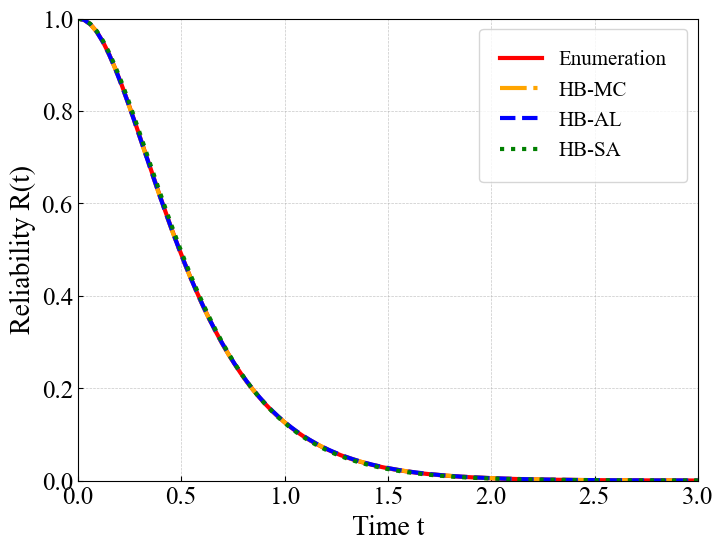

In [8]:
## network reliability ##
t_values = np.linspace(0.0001,3, 100)
R_exact = np.load('R_exact.npy')
R_MCSPH = np.load('R_MCSPH1.npy')
R_DNN = np.load('R_DNN1.npy')
R_AL = np.load('R_AL1.npy')

plt.figure(figsize=(8, 6))
plt.plot(t_values, R_exact, label='Enumeration', linestyle='-', linewidth=3, color='red')
plt.plot(t_values, R_MCSPH, label='HB-MC', linestyle='-.', linewidth=3, color='orange')
plt.plot(t_values, R_AL, label='HB-AL', linestyle='--', linewidth=3, color='blue')
plt.plot(t_values, R_DNN, label='HB-SA', linestyle=':', linewidth=3, color='green')
plt.xlabel('Time t', fontsize=20, fontname='Times New Roman')
plt.ylabel('Reliability R(t)', fontsize=20, fontname='Times New Roman')
# plt.title('Ex1: Network Reliability', fontsize=16)
plt.tick_params(axis='both', direction='in')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper right', frameon=True, borderpad=1, prop={'family': 'Times New Roman', 'size':15})
plt.xlim(0, 3) 
plt.ylim(0, 1)
aa=18
plt.xticks(fontsize=aa, fontname='Times New Roman')
plt.yticks(fontsize=aa, fontname='Times New Roman')
plt.savefig('0406result_total_R3.png', bbox_inches='tight')
plt.show()

In [9]:
#========================================
## network reliability error analysis ##
#========================================
ae2 = np.sqrt(np.sum(R_exact**2))

## HB-MC ##
abs_err_MCSPH = np.abs(R_MCSPH - R_exact)
AE_L2_MCSPH = np.sqrt(np.sum(abs_err_MCSPH**2))
RE_L2_MCSPH = AE_L2_MCSPH / ae2
MSE_MCSPH   = np.mean(abs_err_MCSPH**2)
print("\n===== Network Reliability Error: HB-MC =====")
print(f"AE_L2_HBMC: {AE_L2_MCSPH}")
print(f"RE_L2_HBMC: {RE_L2_MCSPH}")
print(f"MSE_HBMC:   {MSE_MCSPH}")

## HB-AL ##
abs_err_AL = np.abs(R_AL - R_exact)
AE_L2_MCSPH_DNN_AL = np.sqrt(np.sum(abs_err_AL**2))
RE_L2_MCSPH_DNN_AL = AE_L2_MCSPH_DNN_AL / ae2
MSE_MCSPH_DNN_AL   = np.mean(abs_err_AL**2)
print("\n===== Network Reliability Error: HB-AL =====")
print(f"AE_L2_HB_AL: {AE_L2_MCSPH_DNN_AL}")
print(f"RE_L2_HB_AL: {RE_L2_MCSPH_DNN_AL}")
print(f"MSE_HB_AL:   {MSE_MCSPH_DNN_AL}")

## HB-SA ##
abs_err_DNN = np.abs(R_DNN - R_exact)
AE_L2_MCSPH_DNN = np.sqrt(np.sum(abs_err_DNN**2))
RE_L2_MCSPH_DNN = AE_L2_MCSPH_DNN / ae2
MSE_MCSPH_DNN   = np.mean(abs_err_DNN**2)
print("\n===== Network Reliability Error: HB-SA =====")
print(f"AE_L2_HB_SA: {AE_L2_MCSPH_DNN}")
print(f"RE_L2_HB_SA: {RE_L2_MCSPH_DNN}")
print(f"MSE_HB_SA:   {MSE_MCSPH_DNN}")


===== Network Reliability Error: HB-MC =====
AE_L2_HBMC: 0.006186592661018952
RE_L2_HBMC: 0.0017333404472291171
MSE_HBMC:   3.827392875337356e-07

===== Network Reliability Error: HB-AL =====
AE_L2_HB_AL: 0.004904989760661514
RE_L2_HB_AL: 0.0013742649001233839
MSE_HB_AL:   2.4058924552194295e-07

===== Network Reliability Error: HB-SA =====
AE_L2_HB_SA: 0.02774485946046186
RE_L2_HB_SA: 0.007773469135688202
MSE_HB_SA:   7.6977722648078e-06


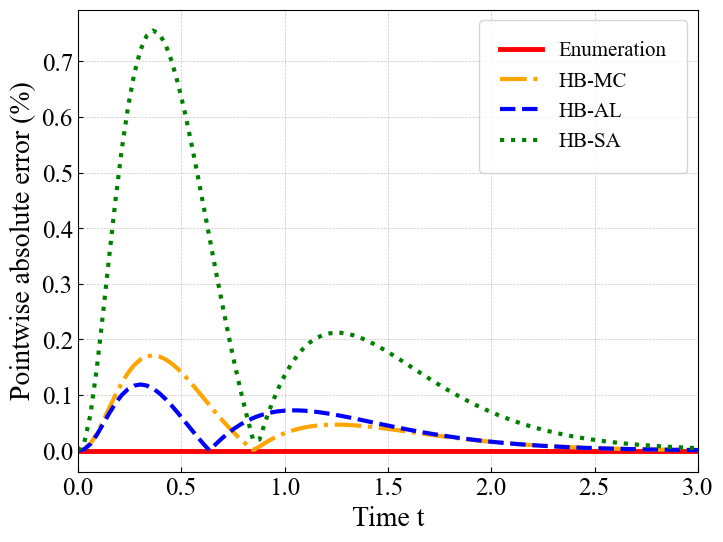

In [10]:
## pointwise absolute error ## 
AE_exact= abs(R_exact-R_exact)

plt.figure(figsize=(8, 6))
plt.plot(t_values, AE_exact*100, label='Enumeration', linestyle='-', linewidth=3.5, color='red')
plt.plot(t_values, abs_err_MCSPH*100, label='HB-MC', linestyle='-.', linewidth=3, color='orange')
plt.plot(t_values, abs_err_AL*100, label='HB-AL', linestyle='--', linewidth=3, color='blue')
plt.plot(t_values, abs_err_DNN*100, label='HB-SA', linestyle=':', linewidth=3, color='green')

plt.xlabel('Time t', fontsize=20, fontname='Times New Roman')
plt.ylabel('Pointwise absolute error (%)', fontsize=20, fontname='Times New Roman')
# plt.title('Ex1: Network Reliability', fontsize=16)
plt.tick_params(axis='both', direction='in')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper right', frameon=True, borderpad=1, prop={'family': 'Times New Roman', 'size':15})
plt.xlim(0, 3) 
# plt.ylim(0, 0.35)
plt.xticks(fontsize=aa, fontname='Times New Roman')
plt.yticks(fontsize=aa, fontname='Times New Roman')
plt.savefig('0406result_total_AE3.png', bbox_inches='tight')
plt.show()


## Variant network

In [11]:

edges = [(1, 2), (2, 3), (1, 4), (2, 5), (3, 6), (4, 5), 
         (5, 6), (4, 7), (5, 8), (6, 9), (7, 8), (8, 9)]
nodes = set(node for edge in edges for node in edge)
terminals = [1, 9];    
num_nodes = len(nodes)   
num_edges = len(edges)  
num_terminals =len(terminals)

S_v=4;    
exp_nodes_lambda12_v = [3, 5]        
exp_nodes_lambda07_v = [2, 4, 6, 8]  
infinite_nodes_v    = [1, 9]         

weibull_edges_v = [1, 2, 6, 7, 12] 
lognorm_edges_v = [3, 4, 5, 9, 10]  

n1_v = len(exp_nodes_lambda12_v)   
n2_v = len(exp_nodes_lambda07_v)   
n3_v = len(weibull_edges_v)        
n4_v = len(lognorm_edges_v)       
N_v = [n1_v, n2_v, n3_v, n4_v]

lambda1 = 1.2
lambda2 = 0.7
weibull_a = 1.5; weibull_b = 3.6
lognorm_mu = 1.5; lognorm_sigma = 2.6

def F_exp1(t):
    return 1 - np.exp(-lambda1 * t)
def F_exp2(t):
    return 1 - np.exp(-lambda2 * t)
def F_weibull(t):
    return 1 - np.exp(-((t / weibull_b) ** weibull_a))
def F_lognormal(t):
    return norm.cdf(np.log(t), lognorm_mu, lognorm_sigma)
F_v = [F_exp1, F_exp2, F_weibull, F_lognormal]

S11_v = [idx - 1 for idx in exp_nodes_lambda12_v]                
S22_v = [idx - 1 for idx in exp_nodes_lambda07_v]              
S33_v = [num_nodes + (idx - 1) for idx in weibull_edges_v]       
S44_v = [num_nodes + (idx - 1) for idx in lognorm_edges_v]       
groups_v = [S11_v, S22_v, S33_v, S44_v]

# ===========================================
x_variant = x_MCSPH
x_variant[:, 6] = 0     
x_variant[:, 16] = 0   
x_variant[:, 19] = 0 

# ================================================
# HB-SA
DNN_model = load_model('result_model_DNN_net3.h5')      
y_DNN_popb1_variant = DNN_model.predict(x_variant)
y_DNN_variant = (y_DNN_popb1_variant > 0.5).astype(int)

# HB-AL
AL_model = load_model('result_model_AL_net3.h5')   
y_AL_popb1_variant = AL_model.predict(x_variant)
y_AL_variant = (y_AL_popb1_variant > 0.5).astype(int)

# ================================================
## network reliability ## 
# ===========================================
l_count_variant = build_l_count(x_variant, groups_v)

# ===========================================
t_values = np.linspace(0.0001,3, 100)
# R_exact_variant=0; 
R_DNN_variant = 0; R_AL_variant=0
R_time1= time.time()
for ls in itertools.product(range(n1_v+1), range(n2_v+1), range(n3_v+1), range(n4_v+1)):
    ss_DNN = survival_signature(ls, l_count_variant, y_DNN_variant)
    ss_AL = survival_signature(ls, l_count_variant, y_AL_variant)

    p = prop(ls, S_v, N_v, F_v, t_values)
    R_DNN_variant   += ss_DNN   * p; 
    R_AL_variant    += ss_AL    * p
   
total_R_time = time.time() - R_time1
print(f"total_R_time: {total_R_time:.6f} s ") 

# ===========================================
np.save(f'./R_AL_variant1.npy', R_AL_variant)
np.save(f'./R_DNN_variant1.npy', R_DNN_variant)


9375/9375 [==============================] - 8s 850us/step
total_R_time: 7.243202 s 


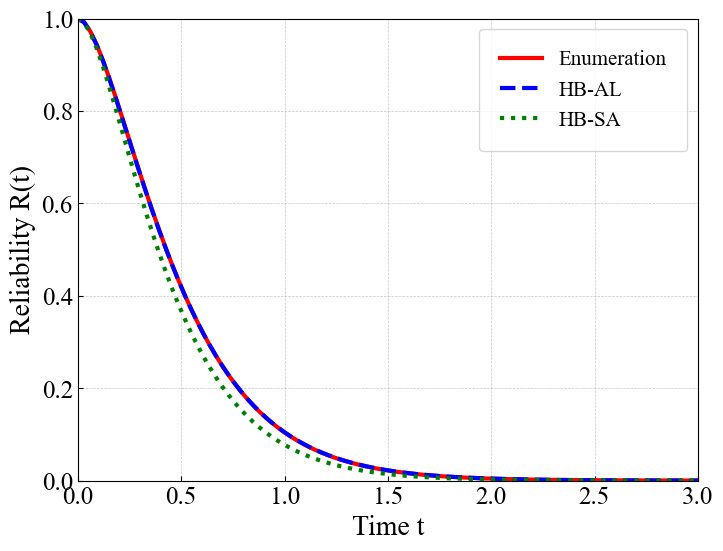

In [12]:
# ===========================================
## network reliability ## 
t_values = np.linspace(0.0001,3, 100)
R_exact_variant=np.load('R_exact_variant.npy')
R_AL_variant=np.load(f'./R_AL_variant1.npy')
R_DNN_variant=np.load(f'./R_DNN_variant1.npy')

plt.figure(figsize=(8, 6))
plt.plot(t_values, R_exact_variant, label='Enumeration', linestyle='-', linewidth=3.0, color='red')
plt.plot(t_values, R_AL_variant, label='HB-AL', linestyle='--', linewidth=3.0, color='blue')
plt.plot(t_values, R_DNN_variant, label='HB-SA', linestyle=':', linewidth=3.0, color='green')

plt.xlabel('Time t', fontsize=20, fontname='Times New Roman')
plt.ylabel('Reliability R(t)', fontsize=20, fontname='Times New Roman')
# plt.title('Ex1: Network Reliability', fontsize=16)
plt.tick_params(axis='both', direction='in')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper right', frameon=True, borderpad=1, prop={'family': 'Times New Roman', 'size':15})
plt.xlim(0, 3) 
plt.ylim(0, 1)
aa=18
plt.xticks(fontsize=aa, fontname='Times New Roman')
plt.yticks(fontsize=aa, fontname='Times New Roman')
plt.savefig('0406result_total_R3_variant.png', bbox_inches='tight')
plt.show()

In [13]:
#========================================
## network reliability error analysis ##
#========================================
ae2_variant = np.sqrt(np.sum(R_exact_variant**2))

## HB-AL ##
abs_err_AL_v = np.abs(R_AL_variant - R_exact_variant)
AE_L2_HBAL_v = np.sqrt(np.sum(abs_err_AL_v**2))
RE_L2_HBAL_v = AE_L2_HBAL_v / ae2_variant
MSE_HBAL_v   = np.mean(abs_err_AL_v**2)
print("\n===== Network Reliability Error: HB-AL =====")
print(f"AE_L2_HB_AL: {AE_L2_HBAL_v}")
print(f"RE_L2_HB_AL: {RE_L2_HBAL_v}")
print(f"MSE_HB_AL:   {MSE_HBAL_v}")

## HB-SA ##
abs_err_DNN_v = np.abs(R_DNN_variant - R_exact_variant)
AE_L2_HBSA_v = np.sqrt(np.sum(abs_err_DNN_v**2))
RE_L2_HBSA_v = AE_L2_HBSA_v / ae2_variant
MSE_HBSA_v   = np.mean(abs_err_DNN_v**2)
print("\n===== Network Reliability Error: HB-SA =====")
print(f"AE_L2_HB_SA: {AE_L2_HBSA_v}")
print(f"RE_L2_HB_SA: {RE_L2_HBSA_v}")
print(f"MSE_HB_SA:   {MSE_HBSA_v}")




===== Network Reliability Error: HB-AL =====
AE_L2_HB_AL: 0.004061719335256083
RE_L2_HB_AL: 0.0012266509828000492
MSE_HB_AL:   1.6497563958393122e-07

===== Network Reliability Error: HB-SA =====
AE_L2_HB_SA: 0.23585669301026732
RE_L2_HB_SA: 0.07122940321595933
MSE_HB_SA:   0.0005562837963773949


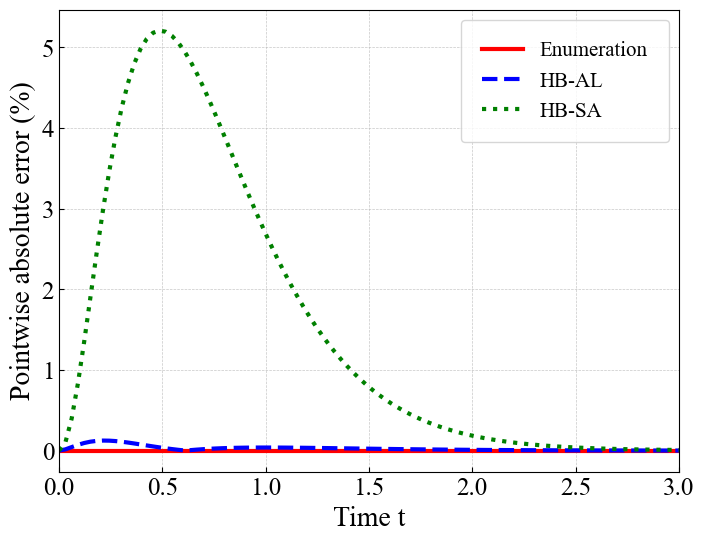

In [14]:
## pointwise absolute error ## 
AE_exact_v= abs(R_exact_variant-R_exact_variant)

plt.figure(figsize=(8, 6))
plt.plot(t_values, AE_exact_v*100, label='Enumeration', linestyle='-', linewidth=3, color='red')
plt.plot(t_values, abs_err_AL_v*100, label='HB-AL', linestyle='--', linewidth=3, color='blue')
plt.plot(t_values, abs_err_DNN_v*100, label='HB-SA', linestyle=':', linewidth=3, color='green')

plt.xlabel('Time t', fontsize=20, fontname='Times New Roman')
plt.ylabel('Pointwise absolute error (%)', fontsize=20, fontname='Times New Roman')
# plt.title('Ex1: Network Reliability', fontsize=16)
plt.tick_params(axis='both', direction='in')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper right', frameon=True, borderpad=1, prop={'family': 'Times New Roman', 'size':15})
plt.xlim(0, 3) 
# plt.ylim(0, 0.35)
plt.xticks(fontsize=aa, fontname='Times New Roman')
plt.yticks(fontsize=aa, fontname='Times New Roman')
plt.savefig('0406result_total_AE3_variant.png', bbox_inches='tight')
plt.show()
